<a href="https://colab.research.google.com/github/maheen-armghan/AI-ANN-and-Deep-learning-projects/blob/main/mnist-neural-network-from-scratch.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/maheen-armghan/AI-ANN-and-Deep-learning-projects/blob/main/Fine_tuned_GPT_2_Art_Text_Generator.ipynb)

In [ ]:
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt


In [ ]:
import kagglehub
path = kagglehub.dataset_download("oddrationale/mnist-in-csv")
print(path)

Using Colab cache for faster access to the 'mnist-in-csv' dataset.
/kaggle/input/mnist-in-csv


In [ ]:
data = pd.read_csv(path + '/mnist_train.csv')
print(data.shape)  # should be (60000, 785)

(60000, 785)


In [ ]:
import os

for folder in os.listdir(path):
    print(folder)

testSample
trainingSample
testSet.tar.gz
trainingSet
testSet
trainingSet.tar.gz


In [ ]:
data = np.array(data)
m, n = data.shape
np.random.shuffle(data)

In [ ]:
data[:5]

array([[6, 0, 0, ..., 0, 0, 0],
       [1, 0, 0, ..., 0, 0, 0],
       [7, 0, 0, ..., 0, 0, 0],
       [4, 0, 0, ..., 0, 0, 0],
       [8, 0, 0, ..., 0, 0, 0]])

In [ ]:
from scipy.ndimage import rotate

def augment_data(X, Y):
    augmented_X = []
    augmented_Y = []

    X_imgs = X.T  # shape (m, 784)

    for i in range(len(X_imgs)):
        img = X_imgs[i].reshape(28, 28)

        # original
        augmented_X.append(img.flatten())
        augmented_Y.append(Y[i])

        # rotated versions
        for angle in [-30, -15, 15, 30]:
            rotated = rotate(img, angle, reshape=False)
            augmented_X.append(rotated.flatten())
            augmented_Y.append(Y[i])

    return np.array(augmented_X).T, np.array(augmented_Y)

# Use before training
X_train_aug, Y_train_aug = augment_data(X_train, Y_train)

In [ ]:
data_dev = data[0:1000].T #data you dont want your data to be trained on
Y_dev = data_dev[0]
X_dev = data_dev[1:n]
X_dev = X_dev / 255.

data_train = data[1000:m].T #.T is the transpose — it flips rows and columns so:
                            #Each column becomes one image, First row becomes labels
Y_train = data_train[0]
X_train = data_train[1:n]
X_train = X_train / 255.
_,m_train = X_train.shape

In [ ]:
Y_train

array([4, 5, 9, ..., 5, 0, 2])

In [ ]:
def init_params():
    W1 = np.random.randn(128, 784) * 0.01
    b1 = np.zeros((128, 1))
    W2 = np.random.randn(64, 128) * 0.01
    b2 = np.zeros((64, 1))
    W3 = np.random.randn(10, 64) * 0.01
    b3 = np.zeros((10, 1))
    return W1, b1, W2, b2, W3, b3
def ReLU(Z):
    return np.maximum(Z, 0)

def softmax(Z):
    A = np.exp(Z) / sum(np.exp(Z))
    return A


In [ ]:
def forward_prop(W1, b1, W2, b2, W3, b3, X):
    Z1 = W1.dot(X) + b1
    A1 = ReLU(Z1)
    Z2 = W2.dot(A1) + b2
    A2 = ReLU(Z2)
    Z3 = W3.dot(A2) + b3
    A3 = softmax(Z3)
    return Z1, A1, Z2, A2, Z3, A3

def ReLU_deriv(Z):
    return Z > 0

#We one-hot encode because the network outputs 10 numbers,
#so the label(input/raw) must also be 10 numbers to calculate the error properly.

def one_hot(Y):
    one_hot_Y = np.zeros((Y.size, Y.max() + 1))
    one_hot_Y[np.arange(Y.size), Y] = 1
    one_hot_Y = one_hot_Y.T
    return one_hot_Y

def back_prop(Z1, A1, Z2, A2, Z3, A3, W2, W3, X, Y):
    m = Y.size
    one_hot_Y = one_hot(Y)

    dZ3 = A3 - one_hot_Y
    dW3 = 1/m * dZ3.dot(A2.T)
    db3 = 1/m * np.sum(dZ3, axis=1, keepdims=True)

    dZ2 = W3.T.dot(dZ3) * ReLU_deriv(Z2)
    dW2 = 1/m * dZ2.dot(A1.T)
    db2 = 1/m * np.sum(dZ2, axis=1, keepdims=True)

    dZ1 = W2.T.dot(dZ2) * ReLU_deriv(Z1)
    dW1 = 1/m * dZ1.dot(X.T)
    db1 = 1/m * np.sum(dZ1, axis=1, keepdims=True)

    return dW1, db1, dW2, db2, dW3, db3

def update_params(W1, b1, W2, b2, W3, b3,
                  dW1, db1, dW2, db2, dW3, db3, alpha):
    W1 -= alpha * dW1
    b1 -= alpha * db1
    W2 -= alpha * dW2
    b2 -= alpha * db2
    W3 -= alpha * dW3
    b3 -= alpha * db3
    return W1, b1, W2, b2, W3, b3

In [ ]:
def get_predictions(A2):
    return np.argmax(A2, 0)

def get_accuracy(predictions, Y):
    print(predictions, Y)
    return np.sum(predictions == Y) / Y.size

"""Gradient descent is an optimization algorithm that minimizes the "cost"
 (error) of a neural network by iteratively updating model weights, moving
 in the opposite direction of the gradient."""

def gradient_descent(X, Y, iterations, alpha):
    W1, b1, W2, b2, W3, b3 = init_params()
    for i in range(iterations):
        Z1,A1,Z2,A2,Z3,A3 = forward_prop(W1,b1,W2,b2,W3,b3,X)
        dW1,db1,dW2,db2,dW3,db3 = back_prop(Z1,A1,Z2,A2,Z3,A3,W2,W3,X,Y)
        W1,b1,W2,b2,W3,b3 = update_params(W1,b1,W2,b2,W3,b3,
                                           dW1,db1,dW2,db2,dW3,db3,alpha)
        if i % 50 == 0:
            print(f"Iteration {i} | Accuracy: {get_accuracy(get_predictions(A3), Y):.4f}")
    return W1, b1, W2, b2, W3, b3

In [ ]:
W1, b1, W2, b2, W3, b3 = gradient_descent(X_train, Y_train, 1000, 0.15)

[9 3 9 ... 9 9 2] [4 5 9 ... 5 0 2]
Iteration 0 | Accuracy: 0.1183
[1 1 1 ... 1 1 1] [4 5 9 ... 5 0 2]
Iteration 50 | Accuracy: 0.1124
[1 1 1 ... 1 1 1] [4 5 9 ... 5 0 2]
Iteration 100 | Accuracy: 0.1124
[1 1 1 ... 1 1 1] [4 5 9 ... 5 0 2]
Iteration 150 | Accuracy: 0.1124
[0 0 0 ... 0 0 0] [4 5 9 ... 5 0 2]
Iteration 200 | Accuracy: 0.2566
[4 6 9 ... 0 0 2] [4 5 9 ... 5 0 2]
Iteration 250 | Accuracy: 0.4966
[4 6 9 ... 2 0 2] [4 5 9 ... 5 0 2]
Iteration 300 | Accuracy: 0.6707
[4 6 9 ... 2 0 2] [4 5 9 ... 5 0 2]
Iteration 350 | Accuracy: 0.7502
[4 6 9 ... 2 0 2] [4 5 9 ... 5 0 2]
Iteration 400 | Accuracy: 0.8048
[4 6 9 ... 5 0 2] [4 5 9 ... 5 0 2]
Iteration 450 | Accuracy: 0.8397
[4 6 9 ... 5 0 2] [4 5 9 ... 5 0 2]
Iteration 500 | Accuracy: 0.8624
[4 6 9 ... 5 0 2] [4 5 9 ... 5 0 2]
Iteration 550 | Accuracy: 0.8779
[4 5 9 ... 5 0 2] [4 5 9 ... 5 0 2]
Iteration 600 | Accuracy: 0.8884
[4 5 9 ... 5 0 2] [4 5 9 ... 5 0 2]
Iteration 650 | Accuracy: 0.8973
[4 5 9 ... 5 0 2] [4 5 9 ... 5 0 2]
I

In [ ]:
def make_predictions(X, W1, b1, W2, b2, W3, b3):
    Z1, A1, Z2, A2, Z3, A3 = forward_prop(W1, b1, W2, b2, W3, b3, X)
    predictions = get_predictions(A3)
    return predictions

def test_prediction(index, W1, b1, W2, b2, W3, b3):
    current_image = X_train[:, index, None]
    prediction = make_predictions(X_train[:, index, None],W1, b1, W2, b2, W3, b3)
    label = Y_train[index]
    print("Prediction: ", prediction)
    print("Label: ", label)

    current_image = current_image.reshape((28, 28)) * 255
    plt.gray()
    plt.imshow(current_image, interpolation='nearest')
    plt.show()


Prediction:  [4]
Label:  4


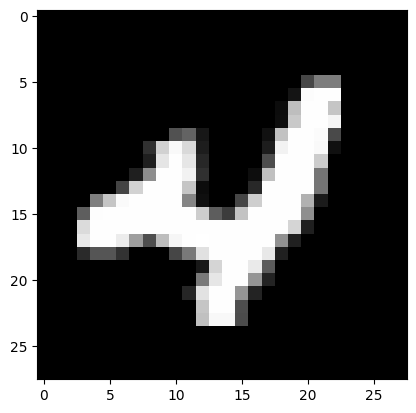

Prediction:  [2]
Label:  2


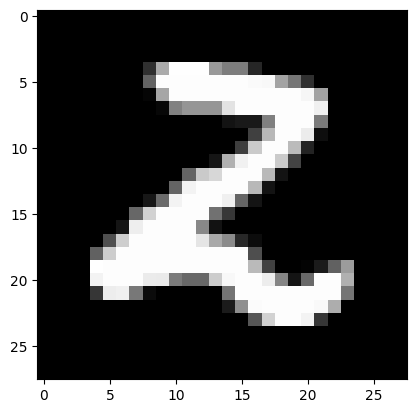

Prediction:  [9]
Label:  9


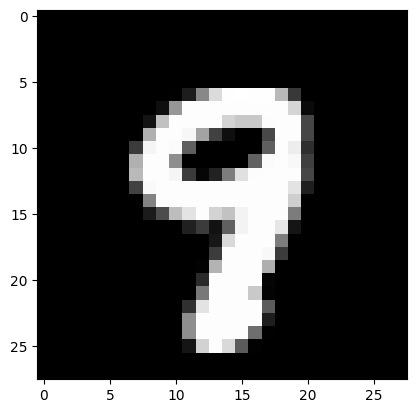

Prediction:  [7]
Label:  7


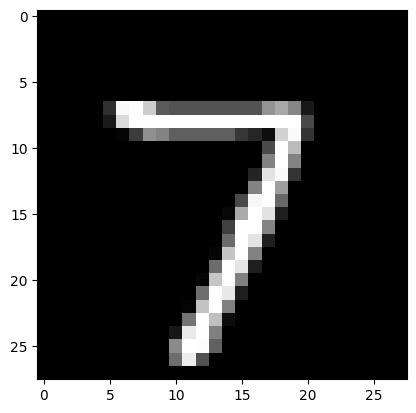

In [ ]:
test_prediction(0, W1, b1, W2, b2, W3, b3)
test_prediction(101, W1, b1, W2, b2, W3, b3)
test_prediction(2, W1, b1, W2, b2, W3, b3)
test_prediction(3, W1, b1, W2, b2, W3, b3)

In [ ]:
dev_predictions = make_predictions(X_dev, W1, b1, W2, b2, W3, b3)
get_accuracy(dev_predictions, Y_dev)

[6 1 7 4 6 0 2 6 2 0 3 6 1 2 9 3 4 0 7 7 6 6 6 1 7 9 3 6 2 7 5 0 3 6 4 6 2
 0 0 3 2 2 4 8 9 6 2 6 1 5 0 8 3 6 0 8 7 0 9 9 8 0 0 2 3 1 3 7 9 9 9 2 2 7
 2 5 7 3 2 2 4 6 0 6 4 8 4 8 8 9 0 9 2 3 3 4 7 1 3 8 7 6 8 7 1 4 3 3 1 3 9
 2 3 5 1 0 2 8 7 1 1 5 4 6 4 8 3 9 8 6 2 9 0 0 3 4 5 8 0 1 2 1 4 1 1 9 3 4
 6 4 6 8 4 5 6 7 6 1 8 3 6 6 8 4 1 4 3 0 1 5 8 8 4 1 9 4 3 3 4 4 2 3 1 8 1
 9 2 3 8 1 5 3 3 5 1 8 3 1 5 7 9 8 5 3 4 6 9 6 9 6 7 5 9 4 2 4 7 5 1 6 9 8
 1 1 8 5 1 5 7 1 5 1 0 5 7 5 9 0 3 1 1 4 0 9 3 4 2 2 1 2 6 4 6 1 4 7 1 5 4
 8 3 0 0 2 7 5 1 1 8 0 1 0 3 2 9 1 2 1 2 6 6 8 1 5 8 6 3 4 4 2 6 4 5 9 8 6
 8 6 3 9 6 4 0 1 1 4 9 7 0 1 0 3 4 7 2 2 0 4 3 0 7 5 9 8 3 8 1 0 4 8 5 3 8
 4 8 2 8 1 2 3 8 1 5 1 1 4 1 4 1 0 6 3 6 8 5 5 2 9 3 2 9 7 0 6 1 3 0 1 1 8
 5 1 3 9 1 6 6 1 6 9 3 0 3 4 4 2 2 9 1 1 5 5 3 2 7 0 7 9 8 6 0 8 4 2 8 0 6
 3 3 9 1 6 8 3 4 1 3 2 9 1 0 7 6 8 7 3 7 1 8 6 5 1 7 7 0 2 2 8 4 1 4 4 8 1
 6 9 0 0 0 8 6 5 3 3 6 4 5 1 8 0 8 6 2 6 1 4 2 2 6 0 6 8 8 6 1 7 9 6 8 1 7
 3 3 0 1 8 8 1 7 2 4 1 6 

np.float64(0.915)